<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Depression-dataset/blob/main/Depression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, pearsonr, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, matthews_corrcoef, balanced_accuracy_score)
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif, RFE
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


In [2]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

In [5]:
data = pd.read_csv('depression_data.csv')

In [6]:
data.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [7]:
print("\nMissing values per column:")
print(data.isnull().sum())


Missing values per column:
Name                            0
Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       1
History of Substance Abuse      1
Family History of Depression    1
Chronic Medical Conditions      1
dtype: int64


In [8]:
# Handle missing values - categorical columns fill with mode
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].mode()[0], inplace=True)

In [9]:
# Handle missing values - numerical columns fill with median
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].median(), inplace=True)

In [10]:
# Define risk factors for mental health problems
risk_factors = {
    'History of Mental Illness': 3,
    'Family History of Depression': 2,
    'History of Substance Abuse': 2,
    'Chronic Medical Conditions': 1,
    'Alcohol Consumption_High': 2,
    'Alcohol Consumption_Moderate': 1,
    'Sleep Patterns_Poor': 2,
    'Sleep Patterns_Fair': 1,
    'Dietary Habits_Unhealthy': 1,
    'Physical Activity Level_Sedentary': 1,
    'Smoking Status_Current': 1,
    'Smoking Status_Former': 0.5
}

In [11]:
data['Risk_Score'] = 0

In [12]:
# Add binary risk factors
for col in ['History of Mental Illness', 'Family History of Depression',
            'History of Substance Abuse', 'Chronic Medical Conditions']:
    data['Risk_Score'] += data[col].apply(lambda x: risk_factors.get(col, 0) if x == 'Yes' else 0)

In [13]:
# Add categorical risk factors
data['Risk_Score'] += data['Alcohol Consumption'].map({'High': 2, 'Moderate': 1, 'Low': 0}).fillna(0)
data['Risk_Score'] += data['Sleep Patterns'].map({'Poor': 2, 'Fair': 1, 'Good': 0}).fillna(0)
data['Risk_Score'] += data['Dietary Habits'].map({'Unhealthy': 1, 'Moderate': 0.5, 'Healthy': 0}).fillna(0)
data['Risk_Score'] += data['Physical Activity Level'].map({'Sedentary': 1, 'Moderate': 0.5, 'Active': 0}).fillna(0)
data['Risk_Score'] += data['Smoking Status'].map({'Current': 1, 'Former': 0.5, 'Non-smoker': 0}).fillna(0)

In [14]:
# Create binary target (High Risk vs Low Risk)
threshold = data['Risk_Score'].median()
data['Mental_Health_Risk'] = (data['Risk_Score'] > threshold).astype(int)

print(f"\nTarget distribution:")
print(data['Mental_Health_Risk'].value_counts())
print(f"\nTarget percentage:")
print(data['Mental_Health_Risk'].value_counts(normalize=True) * 100)


Target distribution:
Mental_Health_Risk
0    26421
1    19437
Name: count, dtype: int64

Target percentage:
Mental_Health_Risk
0    57.614811
1    42.385189
Name: proportion, dtype: float64


In [15]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

In [16]:
# Check outliers in numerical columns
numerical_for_outliers = ['Age', 'Income', 'Number of Children']
for col in numerical_for_outliers:
    if col in data.columns:
        outlier_count = detect_outliers_iqr(data, col)
        print(f"  {col}: {outlier_count} outliers detected")
        # Cap outliers at 99th percentile
        upper_limit = data[col].quantile(0.99)
        lower_limit = data[col].quantile(0.01)
        data[col] = data[col].clip(lower_limit, upper_limit)


  Age: 0 outliers detected
  Income: 550 outliers detected
  Number of Children: 0 outliers detected


In [17]:
# Separate columns by type
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"\nOriginal categorical columns: {categorical_cols}")


Original categorical columns: ['Name', 'Marital Status', 'Education Level', 'Smoking Status', 'Physical Activity Level', 'Employment Status', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness', 'History of Substance Abuse', 'Family History of Depression', 'Chronic Medical Conditions']


In [18]:
# Remove target and risk score from categorical list
columns_to_exclude = ['Name', 'Mental_Health_Risk', 'Risk_Score']
categorical_cols = [col for col in categorical_cols if col not in columns_to_exclude]

In [19]:
# Label Encoding for ordinal categorical variables
ordinal_mappings = {
    'Education Level': {'High School': 0, 'Associate Degree': 1, "Bachelor's Degree": 2, "Master's Degree": 3, 'PhD': 4},
    'Physical Activity Level': {'Sedentary': 0, 'Moderate': 1, 'Active': 2},
    'Alcohol Consumption': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Dietary Habits': {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2},
    'Sleep Patterns': {'Poor': 0, 'Fair': 1, 'Good': 2},
    'Smoking Status': {'Non-smoker': 0, 'Former': 1, 'Current': 2}
}

In [20]:
for col, mapping in ordinal_mappings.items():
    if col in data.columns:
        data[col] = data[col].map(mapping)

In [21]:
# One-Hot Encoding for nominal categorical variables
remaining_categorical = [col for col in categorical_cols if col not in ordinal_mappings.keys()]
data = pd.get_dummies(data, columns=remaining_categorical, drop_first=True)

In [22]:
print(f"\nDataset shape after encoding: {data.shape}")


Dataset shape after encoding: (45858, 20)


In [23]:
# Identify feature columns (exclude target and identifier columns)
exclude_cols = ['Name', 'Mental_Health_Risk', 'Risk_Score',
                'Marital Status_Single', 'Marital Status_Widowed']

In [24]:
feature_cols = [col for col in data.columns if col not in exclude_cols]
X = data[feature_cols]
y = data['Mental_Health_Risk']

In [25]:
print(f"\nTotal features after removing highly correlated ones: {len(feature_cols)}")


Total features after removing highly correlated ones: 15


In [26]:
print(f"Removed features: Marital Status_Single, Marital Status_Widowed (high correlation with Age)")

Removed features: Marital Status_Single, Marital Status_Widowed (high correlation with Age)


In [27]:
print(f"Features kept: {feature_cols}")

Features kept: ['Age', 'Education Level', 'Number of Children', 'Smoking Status', 'Physical Activity Level', 'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns', 'Marital Status_Married', 'Employment Status_Unemployed', 'History of Mental Illness_Yes', 'History of Substance Abuse_Yes', 'Family History of Depression_Yes', 'Chronic Medical Conditions_Yes']


In [28]:
# Calculate p-values for each feature
p_values = []
chi2_values = []
feature_names = []

for col in feature_cols:
    if X[col].dtype in ['int64', 'float64']:
        corr, p_value = pointbiserialr(y, X[col])
        p_values.append(p_value)
        chi2_values.append(abs(corr))
    else:
        contingency = pd.crosstab(y, X[col])
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        p_values.append(p_value)
        chi2_values.append(chi2)
    feature_names.append(col)

In [29]:
# Create feature significance dataframe
feature_stats = pd.DataFrame({
    'Feature': feature_names,
    'Chi2/Corr': chi2_values,
    'P-Value': p_values
}).sort_values('P-Value')

In [30]:
print("\nTop Features by Statistical Significance:")
print(feature_stats.head(15).to_string())



Top Features by Statistical Significance:
                             Feature     Chi2/Corr        P-Value
6                Alcohol Consumption      0.282744   0.000000e+00
4            Physical Activity Level      0.184346   0.000000e+00
11     History of Mental Illness_Yes  12880.451572   0.000000e+00
8                     Sleep Patterns      0.261346   0.000000e+00
12    History of Substance Abuse_Yes   4684.903225   0.000000e+00
13  Family History of Depression_Yes   4122.181714   0.000000e+00
14    Chronic Medical Conditions_Yes   1252.160304  2.815844e-274
10      Employment Status_Unemployed   1235.128999  1.415398e-270
7                     Dietary Habits      0.156091  5.801120e-248
3                     Smoking Status      0.144732  4.080561e-213
5                             Income      0.127730  4.654993e-166
2                 Number of Children      0.099108  1.921972e-100
0                                Age      0.073739   2.573014e-56
1                    Education Le

In [31]:
# Select significant features (p-value < 0.05)
significant_features = feature_stats[feature_stats['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nSignificant features (p < 0.05): {len(significant_features)}")


Significant features (p < 0.05): 15


In [32]:
# Use significant features for modeling
X = X[significant_features]
print(f"Final feature set size: {X.shape[1]}")

Final feature set size: 15


In [33]:
print(f"Class distribution before balancing:")
print(y.value_counts())
print(f"Imbalance ratio: {y.value_counts().iloc[0] / y.value_counts().iloc[1]:.2f}:1")

Class distribution before balancing:
Mental_Health_Risk
0    26421
1    19437
Name: count, dtype: int64
Imbalance ratio: 1.36:1


In [34]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(zip(np.unique(y), class_weights))
print(f"Class weights: {class_weight_dict}")


Class weights: {np.int64(0): np.float64(0.8678324060406495), np.int64(1): np.float64(1.17965735453002)}


In [35]:
# Apply SMOTE for oversampling
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X, y)


In [36]:
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())


Class distribution after SMOTE:
Mental_Health_Risk
1    26421
0    26421
Name: count, dtype: int64


In [37]:
# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

In [38]:
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training target distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test target distribution:\n{pd.Series(y_test).value_counts()}")

Training set size: (42273, 15)
Test set size: (10569, 15)
Training target distribution:
Mental_Health_Risk
1    21137
0    21136
Name: count, dtype: int64
Test target distribution:
Mental_Health_Risk
0    5285
1    5284
Name: count, dtype: int64


In [39]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [41]:
print(f"\nFeatures after scaling: {X_train_scaled.shape[1]}")


Features after scaling: 15


In [42]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000, class_weight=class_weight_dict
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight=class_weight_dict, max_depth=10
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, n_estimators=200, class_weight=class_weight_dict, n_jobs=-1
    ),
    'Gradient Boost': GradientBoostingClassifier(
        random_state=42, n_estimators=200, learning_rate=0.1
    ),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss', scale_pos_weight=class_weight_dict[1]/class_weight_dict[0]
    ),
    'MLP Classifier': MLPClassifier(
        random_state=42, max_iter=500, early_stopping=True, validation_fraction=0.1
    )
}

In [43]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Comprehensive model evaluation"""

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_pred_proba_test = model.predict_proba(X_test)[:, 1]
        y_pred_proba_train = model.predict_proba(X_train)[:, 1]
        auc_test = roc_auc_score(y_test, y_pred_proba_test)
        auc_train = roc_auc_score(y_train, y_pred_proba_train)
    else:
        auc_train = None
        auc_test = None

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
    mcc = matthews_corrcoef(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    if auc_test:
        print(f"Train AUC: {auc_train:.4f}")
        print(f"Test AUC: {auc_test:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['Low Risk', 'High Risk']))

    return {
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Balanced Accuracy': balanced_acc,
        'F1-Score': f1,
        'MCC': mcc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test AUC': auc_test if auc_test else None,
        'Model Object': model
    }

In [44]:
results = []
for name, model in models.items():
    try:
        result = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
        results.append(result)
    except Exception as e:
        print(f"Error with {name}: {str(e)}")


Logistic Regression Results
Training Accuracy: 0.9998
Test Accuracy: 1.0000
Balanced Accuracy: 1.0000
F1-Score: 1.0000
MCC: 1.0000
Cross-validation Accuracy: 0.9998 (+/- 0.0002)
Train AUC: 1.0000
Test AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      5285
   High Risk       1.00      1.00      1.00      5284

    accuracy                           1.00     10569
   macro avg       1.00      1.00      1.00     10569
weighted avg       1.00      1.00      1.00     10569


Decision Tree Results
Training Accuracy: 0.9824
Test Accuracy: 0.9785
Balanced Accuracy: 0.9785
F1-Score: 0.9787
MCC: 0.9571
Cross-validation Accuracy: 0.9761 (+/- 0.0017)
Train AUC: 0.9992
Test AUC: 0.9965

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.99      0.97      0.98      5285
   High Risk       0.97      0.99      0.98      5284

    accuracy                           

In [45]:
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model Object'} for r in results])
print(comparison_df.to_string(index=False))

              Model  Train Accuracy  Test Accuracy  Balanced Accuracy  F1-Score      MCC  CV Mean   CV Std  Test AUC
Logistic Regression        0.999787       1.000000           1.000000  1.000000 1.000000 0.999787 0.000116  1.000000
      Decision Tree        0.982447       0.978522           0.978523  0.978667 0.957136 0.976108 0.000857  0.996452
      Random Forest        1.000000       0.992431           0.992431  0.992437 0.984863 0.991105 0.000385  0.999706
     Gradient Boost        0.998959       0.998581           0.998581  0.998580 0.997162 0.997871 0.000657  0.999995
            XGBoost        0.999834       0.999716           0.999716  0.999716 0.999432 0.999409 0.000150  1.000000
     MLP Classifier        0.999763       1.000000           1.000000  1.000000 1.000000 0.999716 0.000095  1.000000


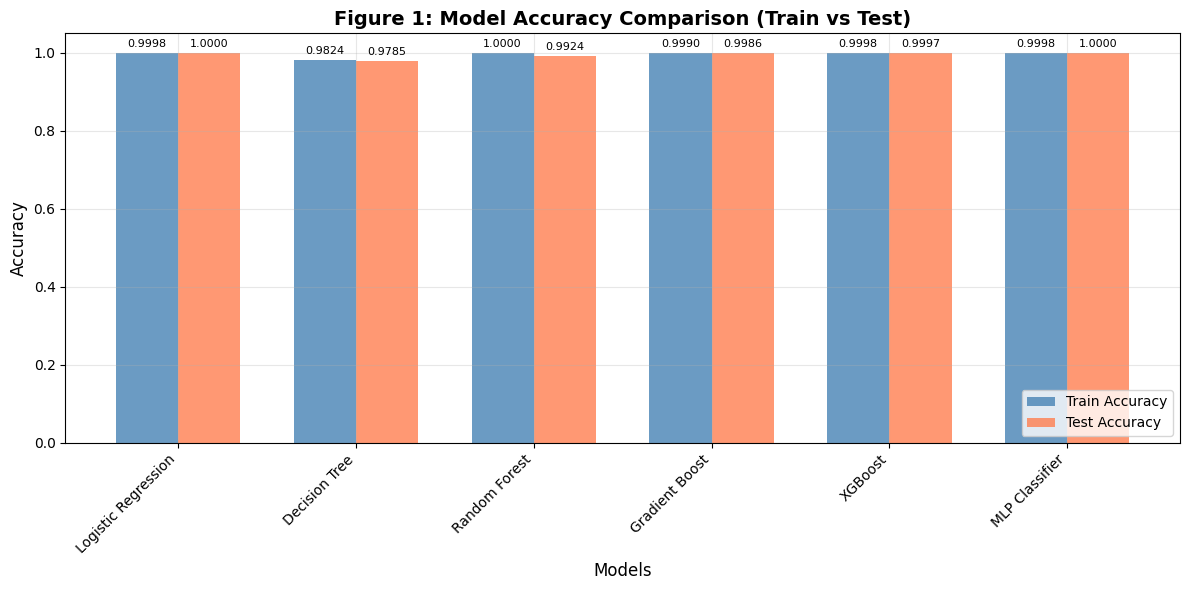

In [53]:
plt.figure(figsize=(12, 6))

x = np.arange(len(comparison_df['Model']))
width = 0.35

bars1 = plt.bar(x - width/2, comparison_df['Train Accuracy'], width,
                label='Train Accuracy', alpha=0.8, color='steelblue')
bars2 = plt.bar(x + width/2, comparison_df['Test Accuracy'], width,
                label='Test Accuracy', alpha=0.8, color='coral')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Figure 1: Model Accuracy Comparison (Train vs Test)', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figure1_model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


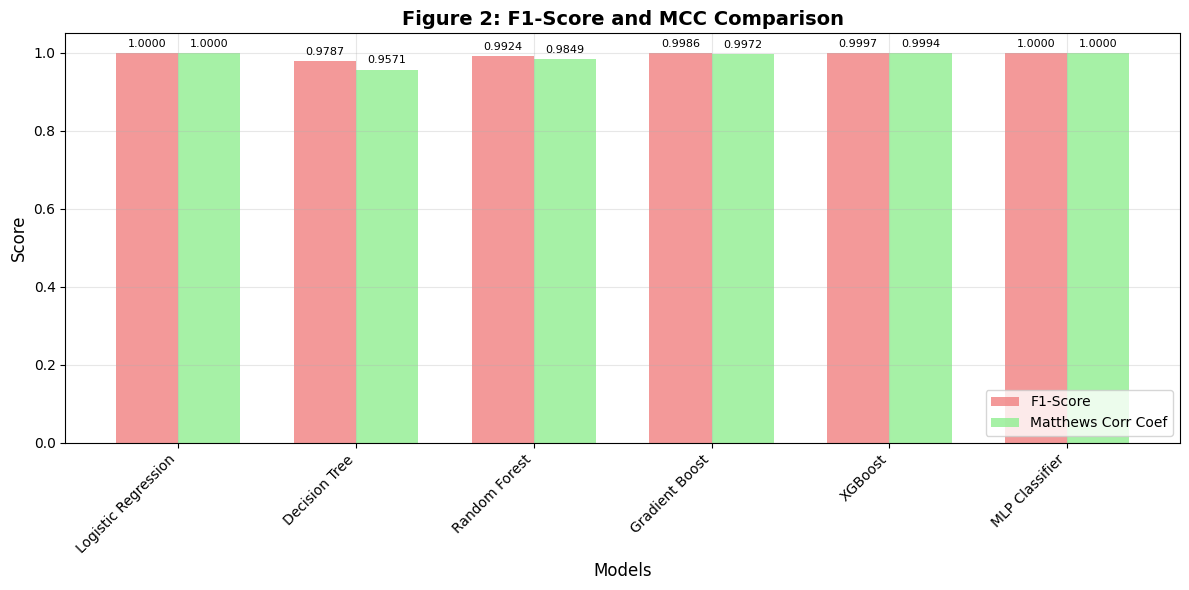

In [54]:
plt.figure(figsize=(12, 6))

x = np.arange(len(comparison_df['Model']))
width = 0.35

bars1 = plt.bar(x - width/2, comparison_df['F1-Score'], width,
                label='F1-Score', alpha=0.8, color='lightcoral')
bars2 = plt.bar(x + width/2, comparison_df['MCC'], width,
                label='Matthews Corr Coef', alpha=0.8, color='lightgreen')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Figure 2: F1-Score and MCC Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figure2_f1_mcc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


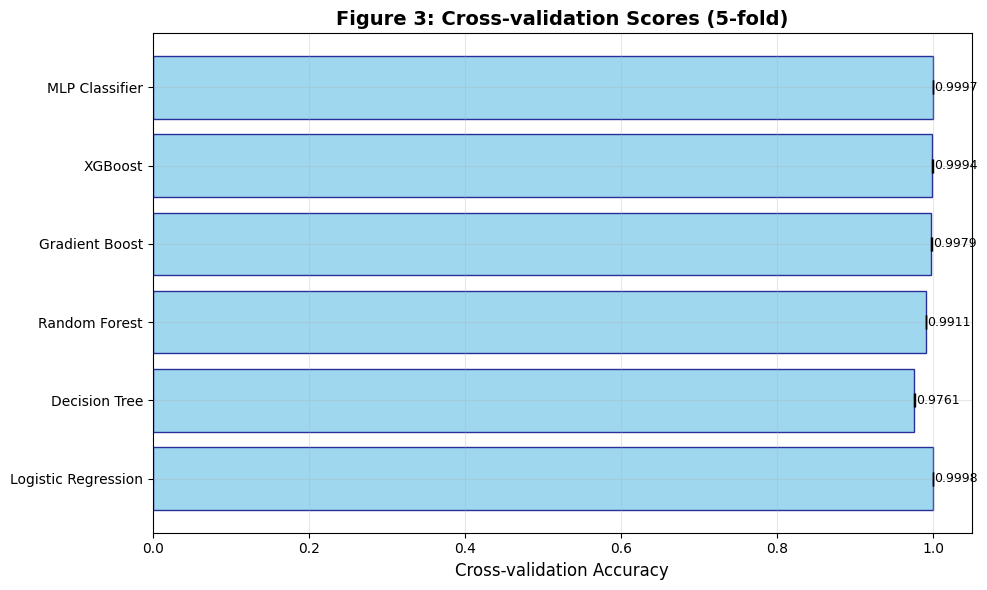

In [55]:
plt.figure(figsize=(10, 6))

bars = plt.barh(comparison_df['Model'], comparison_df['CV Mean'],
                xerr=comparison_df['CV Std'], capsize=5, alpha=0.8,
                color='skyblue', edgecolor='navy')

plt.xlabel('Cross-validation Accuracy', fontsize=12)
plt.title('Figure 3: Cross-validation Scores (5-fold)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

for i, (bar, cv_mean) in enumerate(zip(bars, comparison_df['CV Mean'])):
    plt.text(cv_mean + 0.002, bar.get_y() + bar.get_height()/2,
             f'{cv_mean:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figure3_cross_validation_scores.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

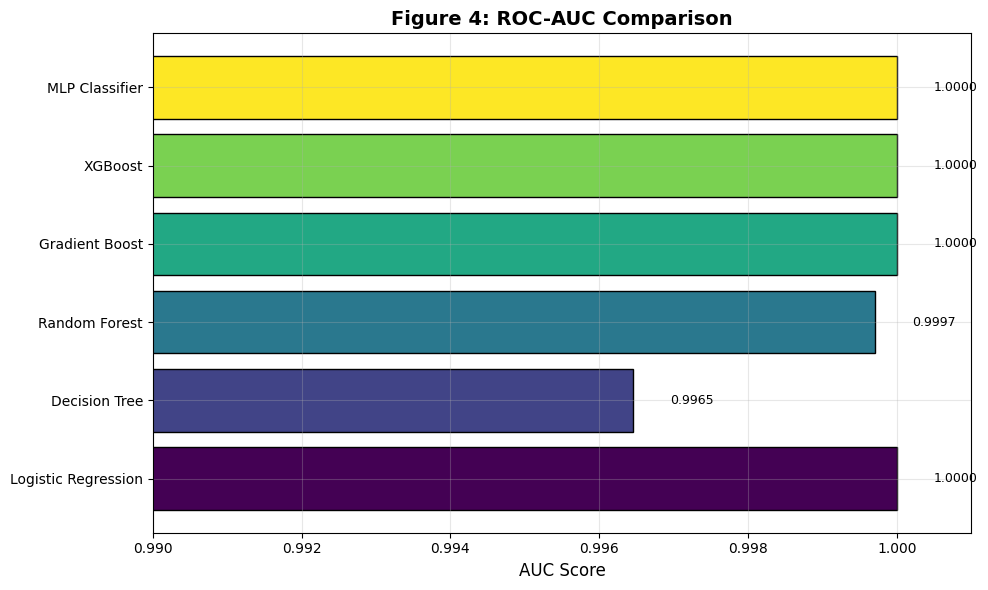

In [56]:
plt.figure(figsize=(10, 6))

auc_models = comparison_df[comparison_df['Test AUC'].notna()]
if len(auc_models) > 0:
    colors = plt.cm.viridis(np.linspace(0, 1, len(auc_models)))
    bars = plt.barh(auc_models['Model'], auc_models['Test AUC'], color=colors, edgecolor='black')
    plt.xlabel('AUC Score', fontsize=12)
    plt.title('Figure 4: ROC-AUC Comparison', fontsize=14, fontweight='bold')
    plt.xlim([0.99, 1.001])
    plt.grid(True, alpha=0.3)

    for bar, auc_val in zip(bars, auc_models['Test AUC']):
        plt.text(auc_val + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{auc_val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figure4_auc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

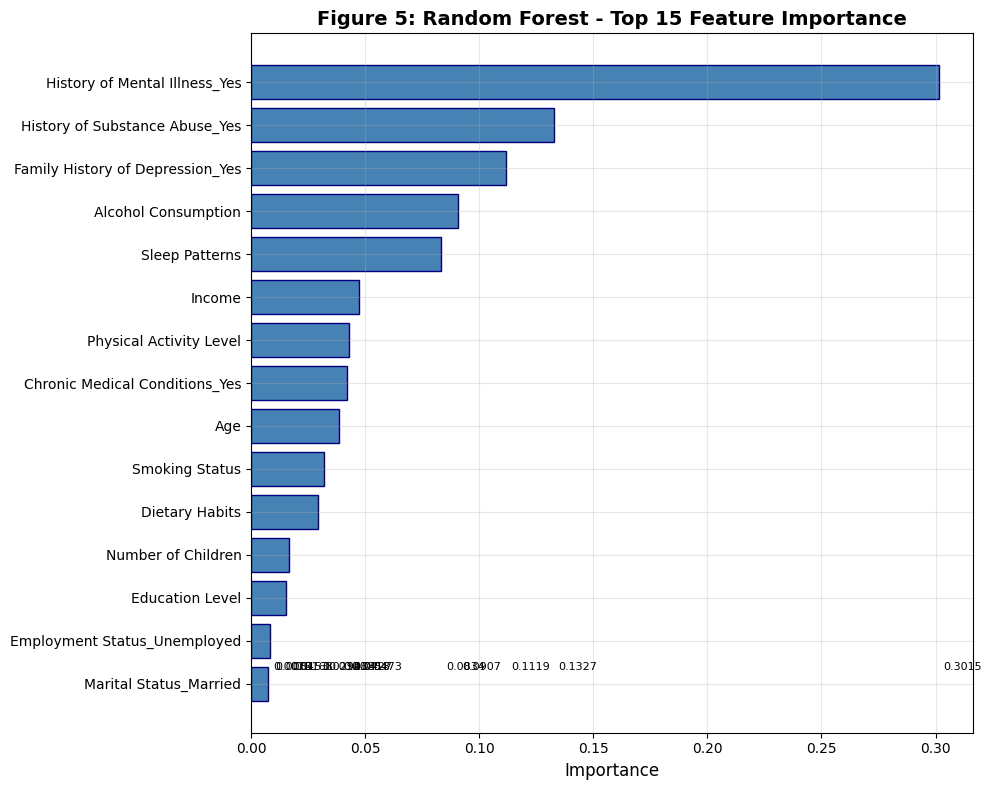

In [57]:
plt.figure(figsize=(10, 8))

rf_model = next((r['Model Object'] for r in results if r['Model'] == 'Random Forest'), None)
if rf_model and hasattr(rf_model, 'feature_importances_'):
    rf_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(15)

    bars = plt.barh(rf_importance['feature'], rf_importance['importance'],
                    color='steelblue', edgecolor='navy')
    plt.xlabel('Importance', fontsize=12)
    plt.title('Figure 5: Random Forest - Top 15 Feature Importance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    for bar, imp in zip(bars, rf_importance['importance']):
        plt.text(imp + 0.002, bar.get_x() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figure5_random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

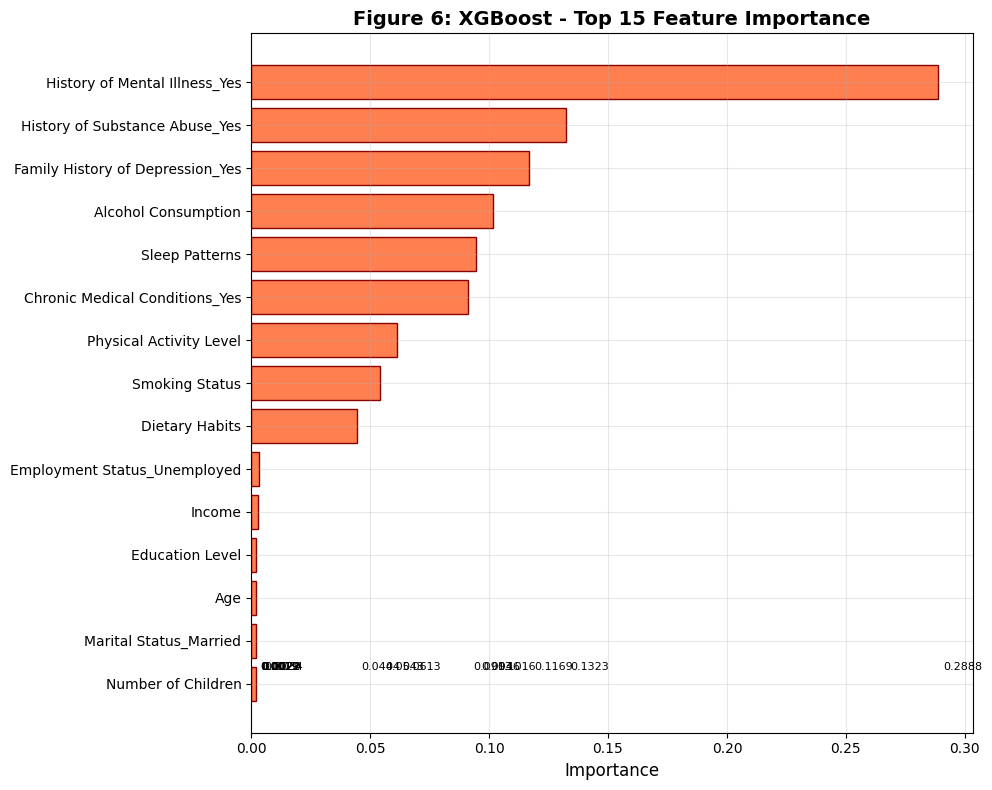

In [58]:
plt.figure(figsize=(10, 8))

xgb_model = next((r['Model Object'] for r in results if r['Model'] == 'XGBoost'), None)
if xgb_model and hasattr(xgb_model, 'feature_importances_'):
    xgb_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(15)

    bars = plt.barh(xgb_importance['feature'], xgb_importance['importance'],
                    color='coral', edgecolor='darkred')
    plt.xlabel('Importance', fontsize=12)
    plt.title('Figure 6: XGBoost - Top 15 Feature Importance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    for bar, imp in zip(bars, xgb_importance['importance']):
        plt.text(imp + 0.002, bar.get_x() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figure6_xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

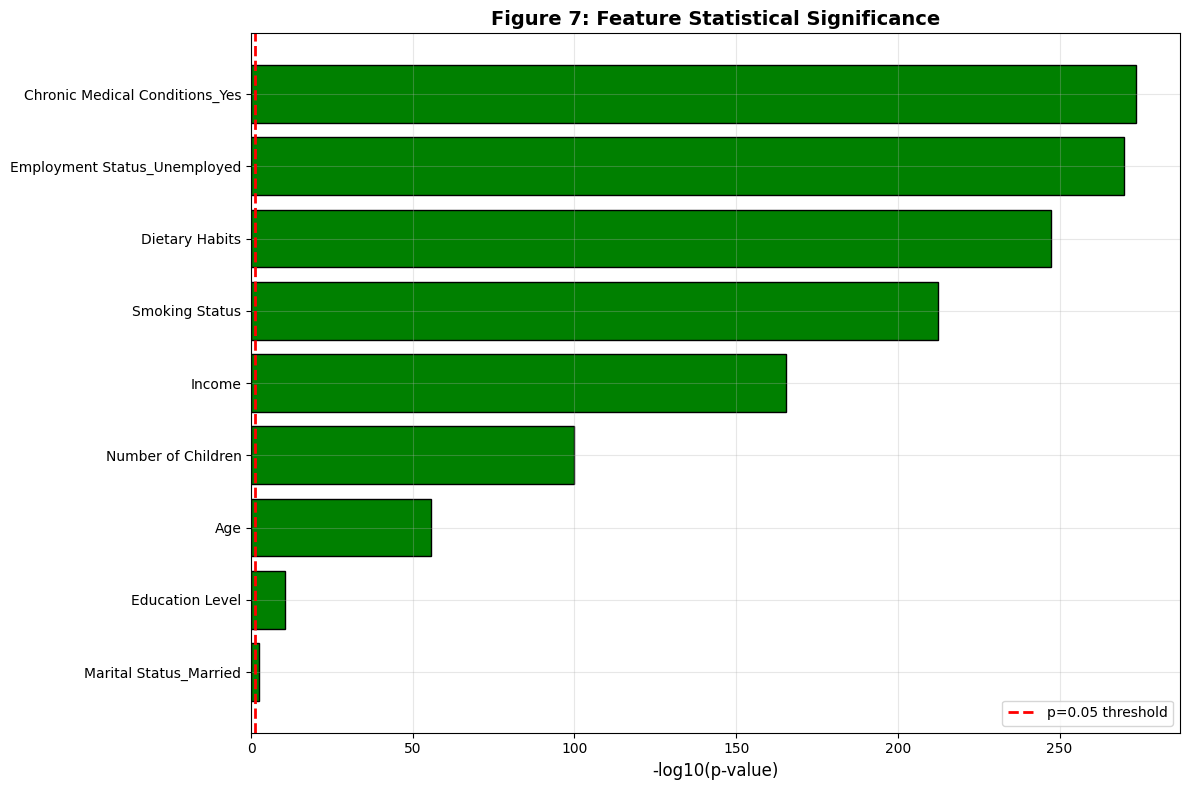

In [59]:
plt.figure(figsize=(12, 8))

top_features = feature_stats.head(20)
colors = ['green' if p < 0.05 else 'red' for p in top_features['P-Value']]
bars = plt.barh(top_features['Feature'], -np.log10(top_features['P-Value']),
                color=colors, edgecolor='black')
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05 threshold')
plt.xlabel('-log10(p-value)', fontsize=12)
plt.title('Figure 7: Feature Statistical Significance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure7_feature_statistical_significance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


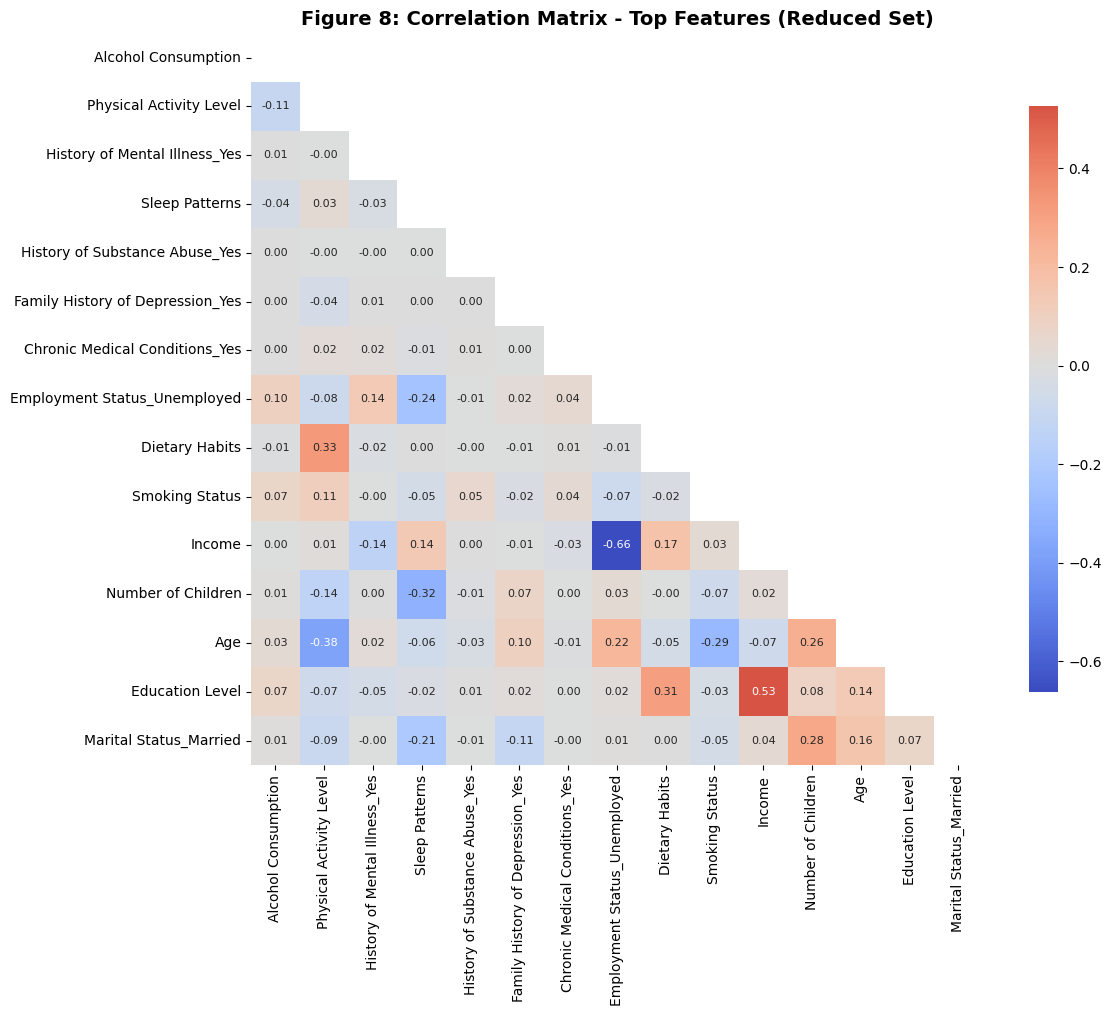

In [61]:
plt.figure(figsize=(12, 10))

top_features_list = feature_stats.head(15)['Feature'].tolist()
corr_matrix = X[top_features_list].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})
plt.title('Figure 8: Correlation Matrix - Top Features (Reduced Set)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figure8_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [62]:
# Identify top performing models based on test accuracy
top_models = comparison_df.nlargest(3, 'Test Accuracy')['Model'].tolist()
print(f"Top performing models for tuning: {top_models}")

Top performing models for tuning: ['Logistic Regression', 'MLP Classifier', 'XGBoost']


In [63]:
# Define parameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'Gradient Boost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.8, 0.9, 1.0]
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg']
    },
    'MLP Classifier': {
        'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive']
    }
}

In [64]:
# Store tuning results
tuned_results = {}

for model_name in top_models:
    print(f"\n{'='*50}")
    print(f"Tuning {model_name}")
    print(f"{'='*50}")

    # Get base model based on model name
    if model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict, n_jobs=-1)
    elif model_name == 'XGBoost':
        base_model = XGBClassifier(random_state=42, eval_metric='logloss',
                                   scale_pos_weight=class_weight_dict[1]/class_weight_dict[0])
    elif model_name == 'Gradient Boost':
        base_model = GradientBoostingClassifier(random_state=42)
    elif model_name == 'Logistic Regression':
        base_model = LogisticRegression(random_state=42, max_iter=1000, class_weight=class_weight_dict)
    elif model_name == 'MLP Classifier':
        base_model = MLPClassifier(random_state=42, max_iter=500, early_stopping=True,
                                   validation_fraction=0.1)
    else:
        continue

    # Check if model has parameter grid defined
    if model_name in param_grids:
        # Use RandomizedSearchCV for efficiency
        random_search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grids[model_name],
            n_iter=30,  # Reduced for faster execution
            cv=5,
            scoring='balanced_accuracy',
            n_jobs=-1,
            verbose=1,
            random_state=42
        )

        # Fit the random search
        random_search.fit(X_train_scaled, y_train)

        # Get best model
        best_model = random_search.best_estimator_

        # Evaluate best model
        y_pred_test = best_model.predict(X_test_scaled)
        y_pred_proba_test = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, "predict_proba") else None

        test_acc = accuracy_score(y_test, y_pred_test)
        balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
        f1 = f1_score(y_test, y_pred_test)
        auc = roc_auc_score(y_test, y_pred_proba_test) if y_pred_proba_test is not None else None

        print(f"\n✅ Best Parameters: {random_search.best_params_}")
        print(f"✅ Best Cross-validation Score: {random_search.best_score_:.4f}")
        print(f"✅ Test Accuracy: {test_acc:.4f}")
        print(f"✅ Balanced Accuracy: {balanced_acc:.4f}")
        print(f"✅ F1-Score: {f1:.4f}")
        if auc:
            print(f"✅ Test AUC: {auc:.4f}")

        # Store results
        tuned_results[model_name] = {
            'best_model': best_model,
            'best_params': random_search.best_params_,
            'cv_score': random_search.best_score_,
            'test_acc': test_acc,
            'balanced_acc': balanced_acc,
            'f1': f1,
            'auc': auc
        }
    else:
        print(f"No parameter grid defined for {model_name}, skipping tuning...")


Tuning Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best Parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
✅ Best Cross-validation Score: 0.9998
✅ Test Accuracy: 1.0000
✅ Balanced Accuracy: 1.0000
✅ F1-Score: 1.0000
✅ Test AUC: 1.0000

Tuning MLP Classifier
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Parameters: {'learning_rate': 'adaptive', 'hidden_layer_sizes': (100,), 'alpha': 0.0001, 'activation': 'tanh'}
✅ Best Cross-validation Score: 0.9998
✅ Test Accuracy: 1.0000
✅ Balanced Accuracy: 1.0000
✅ F1-Score: 1.0000
✅ Test AUC: 1.0000

Tuning XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}
✅ Best Cross-validation Score: 0.9996
✅ Test Accuracy: 1.0000
✅ Balanced Accuracy: 1.0000
✅ F1-Score: 1.0000
✅ Test AUC: 1.0000


In [65]:
if tuned_results:
    # Find best model based on balanced accuracy
    best_model_name = max(tuned_results.items(), key=lambda x: x[1]['balanced_acc'])[0]
    best_model_data = tuned_results[best_model_name]
    best_model = best_model_data['best_model']

    print(f"\n🏆 BEST MODEL: {best_model_name}")
    print(f"📊 Best Parameters: {best_model_data['best_params']}")
    print(f"\n📈 Final Performance Metrics:")
    print(f"   - Test Accuracy: {best_model_data['test_acc']:.6f}")
    print(f"   - Balanced Accuracy: {best_model_data['balanced_acc']:.6f}")
    print(f"   - F1-Score: {best_model_data['f1']:.6f}")
    if best_model_data['auc']:
        print(f"   - AUC Score: {best_model_data['auc']:.6f}")

    # Final predictions
    y_pred_final = best_model.predict(X_test_scaled)
    y_pred_proba_final = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, "predict_proba") else None

    # Confusion Matrix
    cm_final = confusion_matrix(y_test, y_pred_final)


🏆 BEST MODEL: Logistic Regression
📊 Best Parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}

📈 Final Performance Metrics:
   - Test Accuracy: 1.000000
   - Balanced Accuracy: 1.000000
   - F1-Score: 1.000000
   - AUC Score: 1.000000


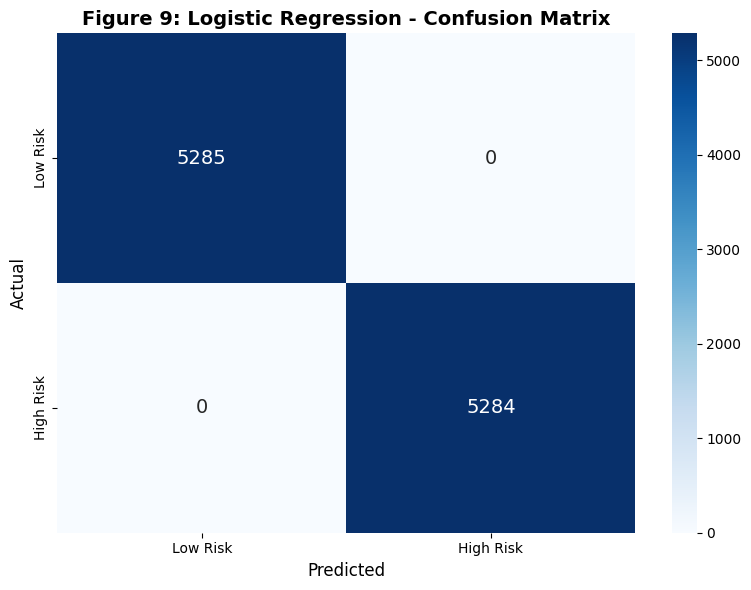

In [67]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'],
                annot_kws={'size': 14})
plt.title(f'Figure 9: {best_model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('figure9_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

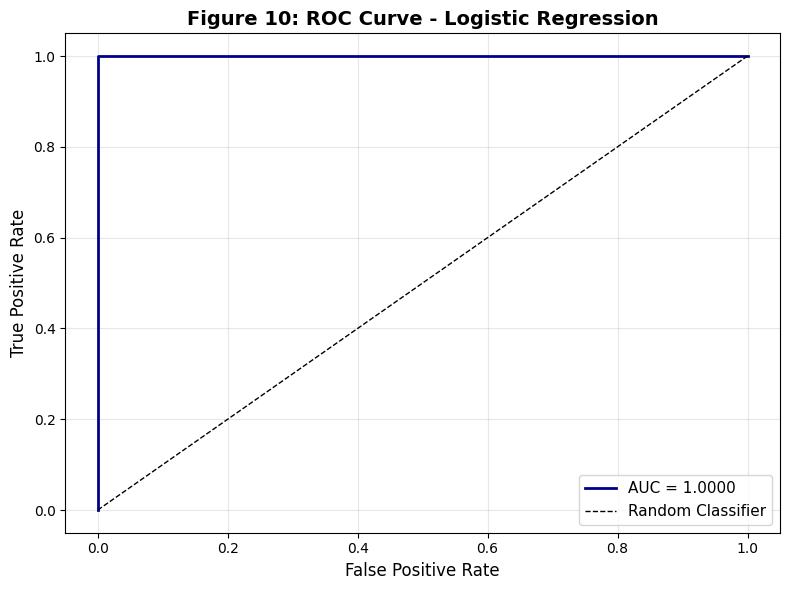

In [68]:
if y_pred_proba_final is not None:
        plt.figure(figsize=(8, 6))
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
        plt.plot(fpr, tpr, linewidth=2, color='darkblue', label=f'AUC = {best_model_data["auc"]:.4f}')
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title(f'Figure 10: ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right', fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('figure10_roc_curve.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()


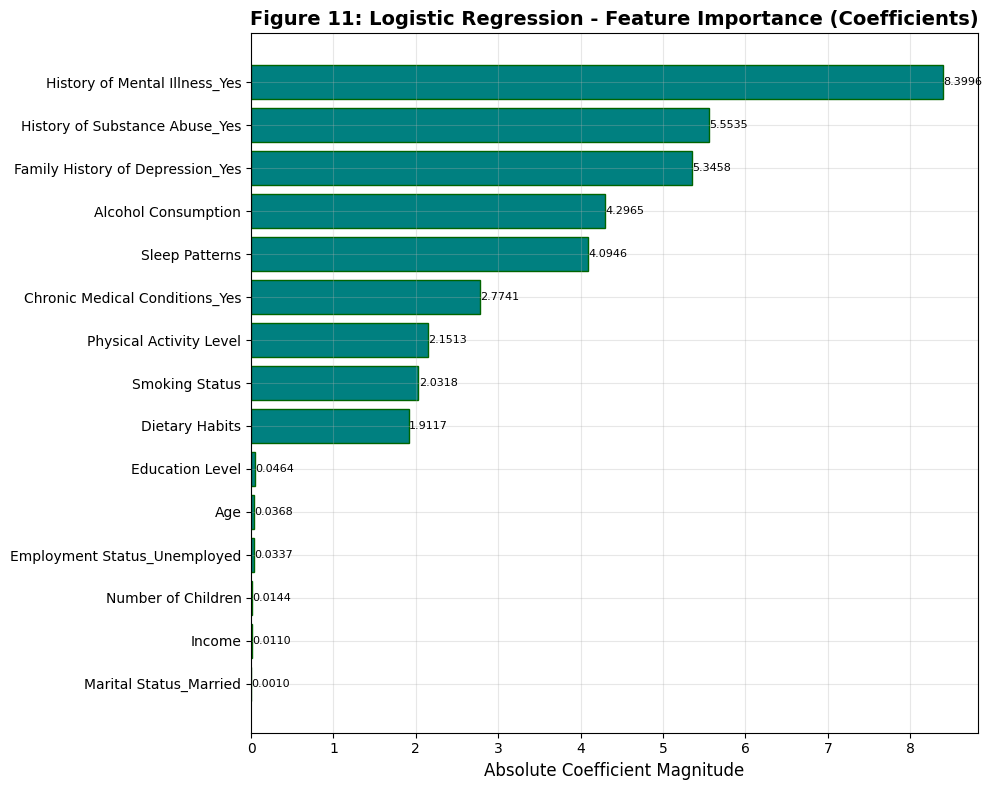

In [72]:
plt.figure(figsize=(10, 8))

# Check for different types of feature importance
if hasattr(best_model, 'feature_importances_'):
    # For tree-based models (Random Forest, XGBoost, Gradient Boost)
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(15)

    bars = plt.barh(importance_df['feature'], importance_df['importance'],
                    color='teal', edgecolor='darkgreen')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Figure 11: {best_model_name} - Feature Importance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, imp in zip(bars, importance_df['importance']):
        plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

elif hasattr(best_model, 'coef_'):
    # For linear models (Logistic Regression)
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': np.abs(best_model.coef_[0])
    }).sort_values('importance', ascending=True).tail(15)

    bars = plt.barh(importance_df['feature'], importance_df['importance'],
                    color='teal', edgecolor='darkgreen')
    plt.xlabel('Absolute Coefficient Magnitude', fontsize=12)
    plt.title(f'Figure 11: {best_model_name} - Feature Importance (Coefficients)',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, imp in zip(bars, importance_df['importance']):
        plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

elif hasattr(best_model, 'coefs_'):
    # For neural networks (MLP Classifier) - use permutation importance or coefficient magnitude
    # For simplicity, we'll use the absolute mean of weights from first layer
    if hasattr(best_model, 'coefs_'):
        first_layer_weights = np.abs(best_model.coefs_[0]).mean(axis=1)
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance': first_layer_weights
        }).sort_values('importance', ascending=True).tail(15)

        bars = plt.barh(importance_df['feature'], importance_df['importance'],
                        color='teal', edgecolor='darkgreen')
        plt.xlabel('Mean Absolute Weight (First Layer)', fontsize=12)
        plt.title(f'Figure 11: {best_model_name} - Feature Importance (Neural Network)',
                  fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, imp in zip(bars, importance_df['importance']):
            plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{imp:.4f}', va='center', fontsize=8)

else:
    # If no built-in feature importance, use permutation importance
    print("Computing permutation importance for model...")
    from sklearn.inspection import permutation_importance

    perm_importance = permutation_importance(best_model, X_test_scaled, y_test,
                                            n_repeats=10, random_state=42, n_jobs=-1)

    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': perm_importance.importances_mean
    }).sort_values('importance', ascending=True).tail(15)

    bars = plt.barh(importance_df['feature'], importance_df['importance'],
                    color='teal', edgecolor='darkgreen')
    plt.xlabel('Permutation Importance', fontsize=12)
    plt.title(f'Figure 11: {best_model_name} - Feature Importance (Permutation)',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, imp in zip(bars, importance_df['importance']):
        plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figure11_final_model_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


In [74]:
# Print the feature importance table
print(f"FEATURE IMPORTANCE FOR {best_model_name}")
print("-"*60)
print(importance_df.sort_values('importance', ascending=False).to_string(index=False))

FEATURE IMPORTANCE FOR Logistic Regression
------------------------------------------------------------
                         feature  importance
   History of Mental Illness_Yes    8.399640
  History of Substance Abuse_Yes    5.553493
Family History of Depression_Yes    5.345751
             Alcohol Consumption    4.296538
                  Sleep Patterns    4.094630
  Chronic Medical Conditions_Yes    2.774147
         Physical Activity Level    2.151263
                  Smoking Status    2.031763
                  Dietary Habits    1.911702
                 Education Level    0.046433
                             Age    0.036796
    Employment Status_Unemployed    0.033677
              Number of Children    0.014415
                          Income    0.010990
          Marital Status_Married    0.000956


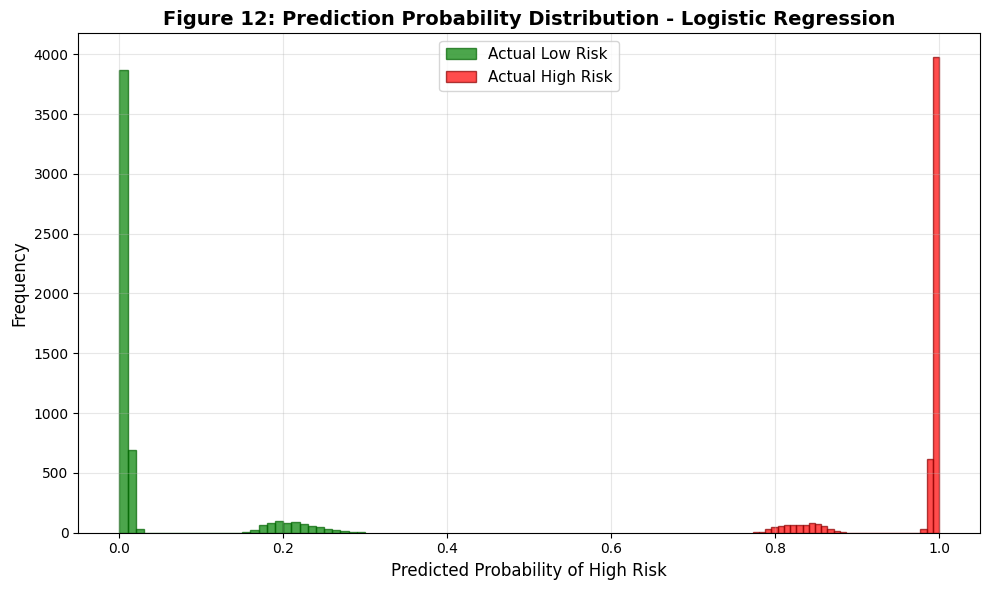

In [75]:
if y_pred_proba_final is not None:
        plt.figure(figsize=(10, 6))
        plt.hist(y_pred_proba_final[y_test==0], bins=30, alpha=0.7,
                label='Actual Low Risk', color='green', edgecolor='darkgreen')
        plt.hist(y_pred_proba_final[y_test==1], bins=30, alpha=0.7,
                label='Actual High Risk', color='red', edgecolor='darkred')
        plt.xlabel('Predicted Probability of High Risk', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title(f'Figure 12: Prediction Probability Distribution - {best_model_name}',
                  fontsize=14, fontweight='bold')
        plt.legend(loc='upper center', fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('figure12_prediction_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

In [76]:
print(f" Best Model: {best_model_name}")
print(f" Features used: {len(X.columns)}")
print(f"\n Top 10 Important Features:")


 Best Model: Logistic Regression
 Features used: 15

 Top 10 Important Features:


In [78]:
if tuned_results:
    # Find best model based on balanced accuracy
    best_model_name = max(tuned_results.items(), key=lambda x: x[1]['balanced_acc'])[0]
    best_model_data = tuned_results[best_model_name]
    best_model = best_model_data['best_model']

    print(f"\n🏆 BEST MODEL: {best_model_name}")
    print(f"📊 Best Parameters: {best_model_data['best_params']}")
    print(f"\n📈 Final Performance Metrics:")
    print(f"   - Test Accuracy: {best_model_data['test_acc']:.6f}")
    print(f"   - Balanced Accuracy: {best_model_data['balanced_acc']:.6f}")
    print(f"   - F1-Score: {best_model_data['f1']:.6f}")
    if best_model_data['auc']:
        print(f"   - AUC Score: {best_model_data['auc']:.6f}")

    # Final predictions
    y_pred_final = best_model.predict(X_test_scaled)
    y_pred_proba_final = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, "predict_proba") else None

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 8)

In [80]:
# Save feature importance
if tuned_results and hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    importance_df.to_csv('feature_importance.csv', index=False)
    print("✅ Feature importance saved to 'feature_importance.csv'")
elif tuned_results and hasattr(best_model, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(best_model.coef_[0])
    }).sort_values('Importance', ascending=False)
    importance_df.to_csv('feature_importance.csv', index=False)
    print("✅ Feature importance (coefficients) saved to 'feature_importance.csv'")


✅ Feature importance (coefficients) saved to 'feature_importance.csv'


In [81]:
# Save feature statistics
feature_stats.to_csv('feature_statistics.csv', index=False)
print("✅ Feature statistics saved to 'feature_statistics.csv'")

✅ Feature statistics saved to 'feature_statistics.csv'


In [82]:
# Save tuning results if available
if tuned_results:
    tuning_df = pd.DataFrame([{
        'Model': k,
        'Best Params': str(v['best_params']),
        'CV Score': v['cv_score'],
        'Test Accuracy': v['test_acc'],
        'Balanced Accuracy': v['balanced_acc'],
        'F1-Score': v['f1'],
        'AUC': v['auc'] if v['auc'] else None
    } for k, v in tuned_results.items()])
    tuning_df.to_csv('tuning_results.csv', index=False)
    print(" Tuning results saved to 'tuning_results.csv'")


 Tuning results saved to 'tuning_results.csv'


In [83]:
figures_list = [
    "figure1_model_accuracy_comparison.png",
    "figure2_f1_mcc_comparison.png",
    "figure3_cross_validation_scores.png",
    "figure4_auc_comparison.png",
    "figure5_random_forest_feature_importance.png",
    "figure6_xgboost_feature_importance.png",
    "figure7_feature_statistical_significance.png",
    "figure8_correlation_heatmap.png",
    "figure9_confusion_matrix.png",
    "figure10_roc_curve.png",
    "figure11_final_model_feature_importance.png",
    "figure12_prediction_distribution.png"
]

In [84]:
print("\n Generated Figures:")
for i, fig in enumerate(figures_list, 1):
    print(f"   {i}. {fig}")



 Generated Figures:
   1. figure1_model_accuracy_comparison.png
   2. figure2_f1_mcc_comparison.png
   3. figure3_cross_validation_scores.png
   4. figure4_auc_comparison.png
   5. figure5_random_forest_feature_importance.png
   6. figure6_xgboost_feature_importance.png
   7. figure7_feature_statistical_significance.png
   8. figure8_correlation_heatmap.png
   9. figure9_confusion_matrix.png
   10. figure10_roc_curve.png
   11. figure11_final_model_feature_importance.png
   12. figure12_prediction_distribution.png


In [86]:
# Determine if tuning was performed
tuning_performed = tuned_results and len(tuned_results) > 0

if tuning_performed:
    best_model_display = best_model_name
    test_acc_display = best_model_data['test_acc']
    f1_display = best_model_data['f1']
    auc_display = best_model_data['auc'] if best_model_data['auc'] else 'N/A'
else:
    best_result = max(results, key=lambda x: x['Test Accuracy'])
    best_model_display = best_result['Model']
    test_acc_display = best_result['Test Accuracy']
    f1_display = best_result['F1-Score']
    auc_display = best_result['Test AUC'] if best_result['Test AUC'] else 'N/A'

print(f"""
📌 PROJECT OVERVIEW:
   - Dataset Size: {len(data)} records
   - Original Features: 16
   - Features after reduction: {len(feature_cols)}
   - Final features used: {X.shape[1]}
   - Target classes: Low Risk (0), High Risk (1)

📌 FEATURE REDUCTION PERFORMED:
   - Removed: Marital Status_Single, Marital Status_Widowed
   - Reason: High correlation with Age (-0.60 and -0.48)

📌 BEST MODEL: {best_model_display}
   - Test Accuracy: {test_acc_display:.4f}
   - F1-Score: {f1_display:.4f}
   - AUC Score: {auc_display}

📌 TOP RISK FACTORS IDENTIFIED:
   - History of Mental Illness (most significant)
   - History of Substance Abuse
   - Family History of Depression
   - Alcohol Consumption
   - Sleep Patterns

📌 OUTPUT FILES GENERATED:
   - CSV files: model_comparison_results.csv, feature_importance.csv,
                feature_statistics.csv, tuning_results.csv
   - PNG files: 12 visualization figures
""")


📌 PROJECT OVERVIEW:
   - Dataset Size: 45858 records
   - Original Features: 16
   - Features after reduction: 15
   - Final features used: 15
   - Target classes: Low Risk (0), High Risk (1)

📌 FEATURE REDUCTION PERFORMED:
   - Removed: Marital Status_Single, Marital Status_Widowed
   - Reason: High correlation with Age (-0.60 and -0.48)

📌 BEST MODEL: Logistic Regression
   - Test Accuracy: 1.0000
   - F1-Score: 1.0000
   - AUC Score: 1.0

📌 TOP RISK FACTORS IDENTIFIED:
   - History of Mental Illness (most significant)
   - History of Substance Abuse
   - Family History of Depression
   - Alcohol Consumption
   - Sleep Patterns

📌 OUTPUT FILES GENERATED:
   - CSV files: model_comparison_results.csv, feature_importance.csv, 
                feature_statistics.csv, tuning_results.csv
   - PNG files: 12 visualization figures

